# Benchmark Analysis

Clean notebook for comparing benchmark outputs in `outputs/metrics`.

Use this to answer questions like:
- Which method wins overall?
- Is a method competitive in the early phase?
- What are the good cases, and what do they have in common?
- Is error coming from local noise, bias, or drift?

## Setup

Change `BASELINE`, `CANDIDATE`, `TOP_N`, and `TOLERANCE_CURVE_OUTLIER_QUANTILE` as needed. The notebook discovers available benchmark CSVs automatically.

In [35]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
pd.set_option("display.width", 140)

ROOT = Path.cwd()
if not (ROOT / "outputs" / "metrics").exists() and (ROOT.parent / "outputs" / "metrics").exists():
    ROOT = ROOT.parent

METRICS_DIR = ROOT / "outputs" / "metrics"

BASELINE = "offline_dtw"
CANDIDATE = "hmm_train70"
TOP_N = 15
EARLY_FRACTION = 0.5
TOLERANCE_CURVE_OUTLIER_QUANTILE = 0.99

METRICS_DIR

PosixPath('/home/diego/School/SP26/E207DTWHMM/outputs/metrics')

## Load Outputs

In [36]:
KINDS = [
    "tolerance_curve",
    "phase_summary",
    "piece_summary",
    "beat_errors",
    "summary",
    "pairs",
]


def discover_metric_files(metrics_dir: Path) -> pd.DataFrame:
    rows = []
    for path in sorted(metrics_dir.glob("*.csv")):
        kind = next((k for k in KINDS if path.stem.endswith(f"_{k}")), None)
        if kind is None:
            continue
        run_id = path.stem[: -(len(kind) + 1)]
        rows.append({"kind": kind, "run_id": run_id, "path": path})
    return pd.DataFrame(rows)


def load_metric_tables(metrics_dir: Path) -> tuple[pd.DataFrame, dict[str, pd.DataFrame]]:
    files = discover_metric_files(metrics_dir)
    tables = {}
    for kind, group in files.groupby("kind"):
        frames = []
        for row in group.itertuples(index=False):
            frame = pd.read_csv(row.path)
            frame.insert(0, "run_id", row.run_id)
            frames.append(frame)
        tables[kind] = pd.concat(frames, ignore_index=True)
    return files, tables


files, tables = load_metric_tables(METRICS_DIR)
display(files.sort_values(["kind", "run_id"]))

available_methods = sorted(tables.get("summary", pd.DataFrame()).get("method_name", pd.Series(dtype=str)).unique())
print("Available methods:", available_methods)

,kind,run_id,path
0,beat_errors,hmm_train70_least_recordings,/home/diego/School/SP26/E207DTWHMM/outputs/met...
6,beat_errors,offline_dtw_least_recordings,/home/diego/School/SP26/E207DTWHMM/outputs/met...
1,pairs,hmm_train70_least_recordings,/home/diego/School/SP26/E207DTWHMM/outputs/met...
7,pairs,offline_dtw_least_recordings,/home/diego/School/SP26/E207DTWHMM/outputs/met...
2,phase_summary,hmm_train70_least_recordings,/home/diego/School/SP26/E207DTWHMM/outputs/met...
8,phase_summary,offline_dtw_least_recordings,/home/diego/School/SP26/E207DTWHMM/outputs/met...
3,piece_summary,hmm_train70_least_recordings,/home/diego/School/SP26/E207DTWHMM/outputs/met...
9,piece_summary,offline_dtw_least_recordings,/home/diego/School/SP26/E207DTWHMM/outputs/met...
4,summary,hmm_train70_least_recordings,/home/diego/School/SP26/E207DTWHMM/outputs/met...
10,summary,offline_dtw_least_recordings,/home/diego/School/SP26/E207DTWHMM/outputs/met...


Available methods: ['hmm_train70', 'offline_dtw']


## Overall Summary

In [37]:
summary_cols = [
    "run_id",
    "method_name",
    "num_pairs",
    "mean_mae_s",
    "median_mae_s",
    "mean_rmse_s",
    "mean_p95_abs_error_s",
    "mean_within_50ms",
    "mean_within_100ms",
    "mean_within_200ms",
    "mean_within_500ms",
]

summary = tables.get("summary", pd.DataFrame()).copy()
display(summary[[c for c in summary_cols if c in summary.columns]].sort_values("mean_mae_s"))

,run_id,method_name,num_pairs,mean_mae_s,median_mae_s,mean_rmse_s,mean_p95_abs_error_s,mean_within_50ms,mean_within_100ms,mean_within_200ms,mean_within_500ms
1,offline_dtw_least_recordings,offline_dtw,363,0.198612,0.058694,0.309837,0.590664,0.615267,0.773120,0.868582,0.932514
0,hmm_train70_least_recordings,hmm_train70,363,1.344433,0.204839,1.840557,3.451386,0.400277,0.506958,0.618821,0.803566


## Pair-Level Comparison

In [38]:
PAIR_METRICS = [
    "mean_abs_error_s",
    "median_abs_error_s",
    "rmse_s",
    "p95_abs_error_s",
    "within_50ms",
    "within_100ms",
    "within_200ms",
    "within_500ms",
]


def compare_pair_table(pairs: pd.DataFrame, baseline: str, candidate: str) -> pd.DataFrame:
    metrics = [m for m in PAIR_METRICS if m in pairs.columns]
    wide = pairs.pivot_table(index="pair_id", columns="method_name", values=metrics, aggfunc="first")
    rows = []
    for pair_id in wide.index:
        row = {"pair_id": pair_id}
        for metric in metrics:
            base = wide.loc[pair_id, (metric, baseline)] if (metric, baseline) in wide.columns else np.nan
            cand = wide.loc[pair_id, (metric, candidate)] if (metric, candidate) in wide.columns else np.nan
            row[f"baseline_{metric}"] = base
            row[f"candidate_{metric}"] = cand
            row[f"delta_{metric}"] = cand - base
        rows.append(row)
    return pd.DataFrame(rows)


pairs = tables.get("pairs", pd.DataFrame()).copy()
pair_comparison = compare_pair_table(pairs, BASELINE, CANDIDATE) if not pairs.empty else pd.DataFrame()

delta_cols = [c for c in pair_comparison.columns if c.startswith("delta_")]
display(pair_comparison[delta_cols].describe().T)

if "delta_mean_abs_error_s" in pair_comparison.columns:
    print(f"{CANDIDATE} beats {BASELINE} by pair MAE:", int((pair_comparison["delta_mean_abs_error_s"] < 0).sum()), "of", len(pair_comparison))
    display(pair_comparison.sort_values("delta_mean_abs_error_s").head(TOP_N))
    display(pair_comparison.sort_values("delta_mean_abs_error_s").tail(TOP_N))

,count,mean,std,min,25%,50%,75%,max
delta_mean_abs_error_s,363.0,1.145821,3.549916,-0.082948,0.100373,0.143610,0.231907,24.231318
delta_median_abs_error_s,363.0,0.941621,3.392068,-1.770799,0.018962,0.039750,0.087835,23.260181
delta_rmse_s,363.0,1.530720,4.476862,-0.547715,0.167445,0.256922,0.453541,28.953958
delta_p95_abs_error_s,363.0,2.860722,7.772446,-1.500063,0.394832,0.564640,0.976103,51.216390
delta_within_50ms,363.0,-0.214990,0.090458,-0.404145,-0.279793,-0.227979,-0.158031,0.031088
delta_within_100ms,363.0,-0.266161,0.100695,-0.512953,-0.336788,-0.269430,-0.207254,0.036269
delta_within_200ms,363.0,-0.249761,0.096156,-0.575130,-0.316062,-0.243523,-0.186528,0.010363
delta_within_500ms,363.0,-0.128948,0.125044,-0.886010,-0.147668,-0.098446,-0.056995,0.056995


hmm_train70 beats offline_dtw by pair MAE: 5 of 363


,pair_id,baseline_mean_abs_error_s,candidate_mean_abs_error_s,delta_mean_abs_error_s,baseline_median_abs_error_s,candidate_median_abs_error_s,delta_median_abs_error_s,baseline_rmse_s,candidate_rmse_s,delta_rmse_s,baseline_p95_abs_error_s,candidate_p95_abs_error_s,delta_p95_abs_error_s,baseline_within_50ms,candidate_within_50ms,delta_within_50ms,baseline_within_100ms,candidate_within_100ms,delta_within_100ms,baseline_within_200ms,candidate_within_200ms,delta_within_200ms,baseline_within_500ms,candidate_within_500ms,delta_within_500ms
276,Chopin_Op030No2_Rangell-2001_pid9094-19__Chopi...,0.195487,0.112539,-0.082948,0.026304,0.032766,0.006462,0.752288,0.204573,-0.547715,0.837801,0.502399,-0.335402,0.761658,0.626943,-0.134715,0.865285,0.709845,-0.155440,0.922280,0.792746,-0.129534,0.943005,0.948187,0.005181
101,Chopin_Op030No2_Fiorentino-1961_pid9065-14__Ch...,0.155619,0.087677,-0.067942,0.032052,0.036009,0.003957,0.451744,0.188360,-0.263384,1.137136,0.292975,-0.844161,0.694301,0.621762,-0.072539,0.860104,0.777202,-0.082902,0.901554,0.891192,-0.010363,0.922280,0.974093,0.051813
335,Chopin_Op030No2_Sofronitsky-1960_pid5667291-15...,0.138016,0.077879,-0.060137,0.027812,0.025716,-0.002096,0.376129,0.154213,-0.221916,1.053031,0.418358,-0.634673,0.704663,0.720207,0.015544,0.813472,0.844560,0.031088,0.901554,0.865285,-0.036269,0.922280,0.979275,0.056995
140,Chopin_Op030No2_Fou-2005_pid9092-13__Chopin_Op...,0.241002,0.199828,-0.041174,0.034036,0.118866,0.084830,0.679238,0.309781,-0.369458,2.129251,0.629189,-1.500063,0.616580,0.352332,-0.264249,0.787565,0.461140,-0.326425,0.870466,0.632124,-0.238342,0.901554,0.906736,0.005181
280,Chopin_Op030No2_Rangell-2001_pid9094-19__Chopi...,0.227114,0.191468,-0.035646,0.033378,0.083334,0.049957,0.667881,0.342608,-0.325273,1.887795,0.734754,-1.153042,0.616580,0.440415,-0.176166,0.803109,0.512953,-0.290155,0.870466,0.689119,-0.181347,0.911917,0.906736,-0.005181
24,Chopin_Op030No2_Biret-1990_pid9062-19__Chopin_...,0.116835,0.140066,0.023231,0.042381,0.056055,0.013673,0.316947,0.339396,0.022448,0.390703,0.447982,0.057279,0.590674,0.466321,-0.124352,0.823834,0.668394,-0.155440,0.901554,0.818653,-0.082902,0.958549,0.953368,-0.005181
295,Chopin_Op030No2_Rubinstein-1952_pid9075-19__Ch...,0.119799,0.145253,0.025454,0.023673,0.034218,0.010545,0.382558,0.279874,-0.102684,0.465585,0.671454,0.205868,0.766839,0.595855,-0.170984,0.829016,0.673575,-0.155440,0.901554,0.766839,-0.134715,0.948187,0.906736,-0.041451
286,Chopin_Op030No2_Rubinstein-1939_pid9049-19__Ch...,0.052246,0.081630,0.029384,0.024853,0.025035,0.000182,0.141399,0.190718,0.049319,0.152975,0.324004,0.171029,0.772021,0.694301,-0.077720,0.922280,0.797927,-0.124352,0.968912,0.896373,-0.072539,0.984456,0.979275,-0.005181
327,Chopin_Op030No2_Smith-1975_pid9054-19__Chopin_...,0.076966,0.108337,0.031372,0.021451,0.034263,0.012812,0.303311,0.189352,-0.113959,0.102413,0.384993,0.282581,0.787565,0.590674,-0.196891,0.943005,0.673575,-0.269430,0.963731,0.777202,-0.186528,0.963731,0.974093,0.010363
145,Chopin_Op030No2_Francois-1956_pid9070b-02__Cho...,0.043086,0.077711,0.034626,0.024467,0.025011,0.000544,0.084239,0.142851,0.058612,0.148712,0.329878,0.181165,0.792746,0.668394,-0.124352,0.917098,0.777202,-0.139896,0.974093,0.870466,-0.103627,0.994819,0.979275,-0.015544


,pair_id,baseline_mean_abs_error_s,candidate_mean_abs_error_s,delta_mean_abs_error_s,baseline_median_abs_error_s,candidate_median_abs_error_s,delta_median_abs_error_s,baseline_rmse_s,candidate_rmse_s,delta_rmse_s,baseline_p95_abs_error_s,candidate_p95_abs_error_s,delta_p95_abs_error_s,baseline_within_50ms,candidate_within_50ms,delta_within_50ms,baseline_within_100ms,candidate_within_100ms,delta_within_100ms,baseline_within_200ms,candidate_within_200ms,delta_within_200ms,baseline_within_500ms,candidate_within_500ms,delta_within_500ms
164,Chopin_Op030No2_Hatto-2006_pid9073-21__Chopin_...,1.191788,10.246879,9.055091,1.056462,7.730998,6.674535,1.511258,13.554476,12.043218,2.852091,25.557863,22.705772,0.088083,0.056995,-0.031088,0.124352,0.072539,-0.051813,0.191710,0.088083,-0.103627,0.336788,0.170984,-0.165803
230,Chopin_Op030No2_Michelangeli-1971_pid5667269b-...,1.074802,11.803411,10.728609,0.696780,10.475284,9.778504,1.456423,14.015370,12.558946,3.077188,23.777370,20.700182,0.077720,0.005181,-0.072539,0.134715,0.015544,-0.119171,0.212435,0.025907,-0.186528,0.409326,0.046632,-0.362694
357,Chopin_Op030No2_Yaroshinskiy-2005_pid9081-10__...,0.887282,12.426422,11.539140,0.820000,16.546621,15.726621,1.148280,15.116301,13.968021,2.125648,22.569306,20.443658,0.082902,0.036269,-0.046632,0.139896,0.056995,-0.082902,0.259067,0.088083,-0.170984,0.414508,0.176166,-0.238342
282,Chopin_Op030No2_Rangell-2001_pid9094-19__Chopi...,1.301327,14.091045,12.789718,1.047449,10.854014,9.806565,1.748507,16.919908,15.171401,3.004898,31.653157,28.648259,0.067358,0.020725,-0.046632,0.134715,0.020725,-0.113990,0.243523,0.020725,-0.222798,0.362694,0.067358,-0.295337
175,Chopin_Op030No2_Indjic-1988_pid9050-19__Chopin...,0.294283,13.712233,13.417950,0.199932,14.756281,14.556349,0.413945,15.060980,14.647035,0.953905,21.137896,20.183991,0.248705,0.025907,-0.222798,0.347150,0.031088,-0.316062,0.502591,0.036269,-0.466321,0.782383,0.062176,-0.720207
219,Chopin_Op030No2_Magaloff-1977_pid9074f-19__Cho...,0.837655,14.313133,13.475478,0.684161,14.895601,14.211440,1.072211,16.047898,14.975688,2.200290,25.479120,23.278830,0.067358,0.036269,-0.031088,0.093264,0.041451,-0.051813,0.155440,0.062176,-0.093264,0.414508,0.072539,-0.341969
358,Chopin_Op030No2_Yaroshinskiy-2005_pid9081-10__...,2.174760,16.511821,14.337061,1.701995,19.617302,17.915306,2.946681,20.398680,17.451999,6.185467,32.808159,26.622692,0.041451,0.036269,-0.005181,0.051813,0.046632,-0.005181,0.108808,0.072539,-0.036269,0.290155,0.170984,-0.119171
360,Chopin_Op030No2_Yaroshinskiy-2005_pid9081-10__...,2.452485,18.416214,15.963729,1.100953,12.442336,11.341383,3.686082,24.554699,20.868618,7.829710,40.979556,33.149846,0.036269,0.000000,-0.036269,0.072539,0.000000,-0.072539,0.139896,0.020725,-0.119171,0.336788,0.124352,-0.212435
355,Chopin_Op030No2_Yaroshinskiy-2005_pid9081-10__...,1.118259,18.302247,17.183988,0.989354,14.291428,13.302075,1.421365,24.596313,23.174948,2.539506,42.432463,39.892957,0.077720,0.051813,-0.025907,0.119171,0.067358,-0.051813,0.222798,0.082902,-0.139896,0.362694,0.181347,-0.181347
356,Chopin_Op030No2_Yaroshinskiy-2005_pid9081-10__...,0.457843,19.821380,19.363537,0.260272,21.149819,20.889546,0.672905,24.991677,24.318771,1.546866,40.241279,38.694413,0.134715,0.015544,-0.119171,0.217617,0.025907,-0.191710,0.404145,0.046632,-0.357513,0.715026,0.119171,-0.595855


## Phase And Tolerance Views

,run_id,method_name,track_phase,num_predictions,mean_abs_error_s,rmse_s,within_100ms,within_200ms
2,offline_dtw_least_recordings,offline_dtw,early,35211,0.116185,0.359888,0.797989,0.889949
0,hmm_train70_least_recordings,hmm_train70,early,35211,0.606973,1.951364,0.524154,0.637670
3,offline_dtw_least_recordings,offline_dtw,late,34848,0.281898,1.008833,0.747991,0.846993
1,hmm_train70_least_recordings,hmm_train70,late,34848,2.089576,6.994152,0.489583,0.599776


Tolerance curve excludes abs-error outliers above p99%: 18.677s


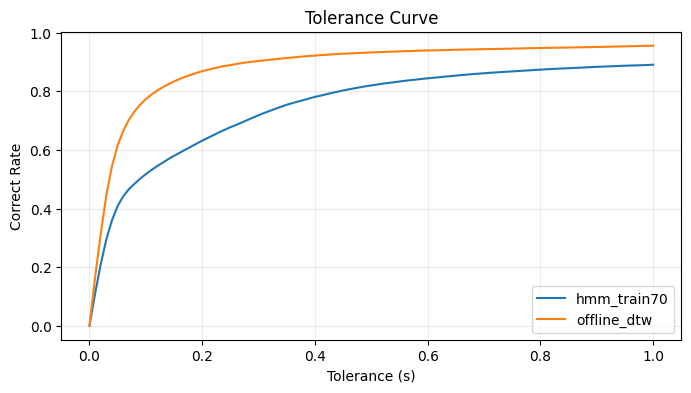

In [39]:
phase_summary = tables.get("phase_summary", pd.DataFrame()).copy()
if not phase_summary.empty:
    display(phase_summary.sort_values(["track_phase", "mean_abs_error_s"]))

def tolerance_curve_without_extreme_outliers(
    beat_errors: pd.DataFrame,
    outlier_quantile: float = TOLERANCE_CURVE_OUTLIER_QUANTILE,
    max_tolerance_s: float = 1.0,
    step_s: float = 0.01,
) -> pd.DataFrame:
    rows = []
    clean = beat_errors.dropna(subset=["abs_error_s"]).copy()
    clean["abs_error_s"] = clean["abs_error_s"].astype(float)
    cutoff_s = float(clean["abs_error_s"].quantile(outlier_quantile))
    clean = clean[clean["abs_error_s"] <= cutoff_s]
    tolerances = np.arange(0.0, max_tolerance_s + (step_s * 0.5), step_s)

    for method, group in clean.groupby("method_name"):
        abs_errors = group["abs_error_s"].to_numpy(dtype=float)
        for tolerance_s in tolerances:
            correct_rate = float(np.mean(abs_errors <= tolerance_s))
            rows.append(
                {
                    "method_name": method,
                    "tolerance_s": float(tolerance_s),
                    "correct_rate": correct_rate,
                    "error_rate": 1.0 - correct_rate,
                    "num_predictions": int(abs_errors.size),
                    "outlier_cutoff_s": cutoff_s,
                }
            )

    return pd.DataFrame(rows)


stored_tolerance = tables.get("tolerance_curve", pd.DataFrame()).copy()
max_tolerance_s = float(stored_tolerance["tolerance_s"].max()) if not stored_tolerance.empty else 1.0
beat_error_rows = tables.get("beat_errors", pd.DataFrame()).copy()
tolerance = (
    tolerance_curve_without_extreme_outliers(beat_error_rows, max_tolerance_s=max_tolerance_s)
    if not beat_error_rows.empty
    else stored_tolerance
)
if not tolerance.empty:
    cutoff_s = tolerance["outlier_cutoff_s"].iloc[0] if "outlier_cutoff_s" in tolerance.columns else tolerance["tolerance_s"].max()
    print(f"Tolerance curve excludes abs-error outliers above p{TOLERANCE_CURVE_OUTLIER_QUANTILE:.0%}: {cutoff_s:.3f}s")
    fig, ax = plt.subplots(figsize=(8, 4))
    for method, group in tolerance.groupby("method_name"):
        group = group.sort_values("tolerance_s")
        ax.plot(group["tolerance_s"], group["correct_rate"], label=method)
    ax.set(title="Tolerance Curve", xlabel="Tolerance (s)", ylabel="Correct Rate")
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.show()

## Beat-Level Early/Late Metrics

If the beat-error CSVs do not include a phase column, this notebook labels the first `EARLY_FRACTION` of beats in each pair as `early`.

In [40]:
def add_track_phase(beat_errors: pd.DataFrame, early_fraction: float = 0.5) -> pd.DataFrame:
    beat_errors = beat_errors.copy()
    total_beats = beat_errors.groupby(["method_name", "pair_id"])["beat_index"].transform("max") + 1
    cutoffs = np.ceil(total_beats * early_fraction).astype(int)
    beat_errors["track_phase"] = np.where(beat_errors["beat_index"] < cutoffs, "early", "late")
    beat_errors["phase_cutoff_beat_index"] = cutoffs
    return beat_errors


def summarize_beat_metrics(beat_errors: pd.DataFrame) -> pd.DataFrame:
    grouped = beat_errors.groupby(["run_id", "method_name", "track_phase", "pair_id"])
    return grouped.agg(
        reference_id=("reference_id", "first"),
        query_id=("query_id", "first"),
        num_beats=("abs_error_s", "size"),
        mae=("abs_error_s", "mean"),
        medae=("abs_error_s", "median"),
        rmse=("error_s", lambda s: float(np.sqrt(np.mean(np.square(s))))),
        p95=("abs_error_s", lambda s: float(np.quantile(s, 0.95))),
        within_50ms=("abs_error_s", lambda s: float((s <= 0.05).mean())),
        within_100ms=("abs_error_s", lambda s: float((s <= 0.10).mean())),
        within_200ms=("abs_error_s", lambda s: float((s <= 0.20).mean())),
        within_500ms=("abs_error_s", lambda s: float((s <= 0.50).mean())),
        bias=("error_s", "mean"),
    ).reset_index()


beat_errors = tables.get("beat_errors", pd.DataFrame()).copy()
beat_errors = add_track_phase(beat_errors, EARLY_FRACTION) if not beat_errors.empty else beat_errors
beat_metrics = summarize_beat_metrics(beat_errors) if not beat_errors.empty else pd.DataFrame()

phase_rollup = beat_metrics.groupby(["method_name", "track_phase"]).agg(
    num_pairs=("pair_id", "nunique"),
    mae=("mae", "mean"),
    medae=("medae", "mean"),
    rmse=("rmse", "mean"),
    p95=("p95", "mean"),
    within_100ms=("within_100ms", "mean"),
    within_200ms=("within_200ms", "mean"),
    within_500ms=("within_500ms", "mean"),
).reset_index()

display(phase_rollup.sort_values(["track_phase", "mae"]))

,method_name,track_phase,num_pairs,mae,medae,rmse,p95,within_100ms,within_200ms,within_500ms
2,offline_dtw,early,363,0.116185,0.070767,0.177579,0.375283,0.797989,0.889949,0.956519
0,hmm_train70,early,363,0.606973,0.400651,0.897071,1.811312,0.524154,0.637670,0.824032
3,offline_dtw,late,363,0.281898,0.242574,0.383834,0.656533,0.747991,0.846993,0.908259
1,hmm_train70,late,363,2.089576,1.991116,2.367620,3.621844,0.489583,0.599776,0.782886


## Early-Phase Comparison

In [41]:
def compare_metric_table(metrics: pd.DataFrame, baseline: str, candidate: str, phase: str = "early") -> pd.DataFrame:
    subset = metrics[metrics["track_phase"] == phase].copy()
    value_cols = ["mae", "medae", "rmse", "p95", "within_50ms", "within_100ms", "within_200ms", "within_500ms", "bias"]
    wide = subset.pivot_table(index="pair_id", columns="method_name", values=value_cols, aggfunc="first")
    rows = []
    for pair_id in wide.index:
        row = {"pair_id": pair_id}
        meta = subset[subset["pair_id"] == pair_id].iloc[0]
        row["reference_id"] = meta["reference_id"]
        row["query_id"] = meta["query_id"]
        for col in value_cols:
            base = wide.loc[pair_id, (col, baseline)] if (col, baseline) in wide.columns else np.nan
            cand = wide.loc[pair_id, (col, candidate)] if (col, candidate) in wide.columns else np.nan
            row[f"baseline_{col}"] = base
            row[f"candidate_{col}"] = cand
            row[f"delta_{col}"] = cand - base
        rows.append(row)
    return pd.DataFrame(rows)


early_comparison = compare_metric_table(beat_metrics, BASELINE, CANDIDATE, phase="early") if not beat_metrics.empty else pd.DataFrame()

display(early_comparison[[c for c in early_comparison.columns if c.startswith("delta_")]].describe().T)

if "delta_mae" in early_comparison.columns:
    print(f"{CANDIDATE} beats {BASELINE} by early MAE:", int((early_comparison["delta_mae"] < 0).sum()), "of", len(early_comparison))
    print(f"{CANDIDATE} beats {BASELINE} by early within-100ms:", int((early_comparison["delta_within_100ms"] > 0).sum()), "of", len(early_comparison))
    display(early_comparison.sort_values("delta_mae").head(TOP_N))

,count,mean,std,min,25%,50%,75%,max
delta_mae,363.0,0.490788,1.226406,-0.169039,0.090861,0.138537,0.220596,10.677181
delta_medae,363.0,0.329885,1.207950,-0.002652,0.016644,0.037064,0.097127,12.131202
delta_rmse,363.0,0.719492,1.562547,-0.369460,0.165902,0.243748,0.391745,12.252096
delta_p95,363.0,1.436029,2.875338,-1.700066,0.348987,0.542508,0.832259,20.039728
delta_within_50ms,363.0,-0.223709,0.102008,-0.494845,-0.288660,-0.226804,-0.164948,0.041237
delta_within_100ms,363.0,-0.273835,0.111049,-0.597938,-0.350515,-0.268041,-0.195876,0.030928
delta_within_200ms,363.0,-0.252279,0.104923,-0.567010,-0.319588,-0.237113,-0.175258,0.000000
delta_within_500ms,363.0,-0.132487,0.132141,-0.835052,-0.154639,-0.092784,-0.051546,0.103093
delta_bias,363.0,-0.372106,1.364252,-10.788098,-0.217566,-0.131325,-0.080631,3.263708


hmm_train70 beats offline_dtw by early MAE: 1 of 363
hmm_train70 beats offline_dtw by early within-100ms: 3 of 363


,pair_id,reference_id,query_id,baseline_mae,candidate_mae,delta_mae,baseline_medae,candidate_medae,delta_medae,baseline_rmse,candidate_rmse,delta_rmse,baseline_p95,candidate_p95,delta_p95,baseline_within_50ms,candidate_within_50ms,delta_within_50ms,baseline_within_100ms,candidate_within_100ms,delta_within_100ms,baseline_within_200ms,candidate_within_200ms,delta_within_200ms,baseline_within_500ms,candidate_within_500ms,delta_within_500ms,baseline_bias,candidate_bias,delta_bias
182,Chopin_Op030No2_Jonas-1947_pid9096-07__Chopin_...,Chopin_Op030No2_Jonas-1947_pid9096-07,Chopin_Op030No2_Shebanova-2002_pid9072-19,0.353191,0.184152,-0.169039,0.045170,0.042518,-0.002652,0.796199,0.426739,-0.369460,2.347274,0.647208,-1.700066,0.536082,0.525773,-0.010309,0.711340,0.639175,-0.072165,0.762887,0.762887,0.000000,0.804124,0.907216,0.103093,-0.323274,-0.124245,0.199029
335,Chopin_Op030No2_Sofronitsky-1960_pid5667291-15...,Chopin_Op030No2_Sofronitsky-1960_pid5667291-15,Chopin_Op030No2_Rangell-2001_pid9094-19,0.040863,0.071042,0.030180,0.027777,0.026734,-0.001043,0.069859,0.133130,0.063271,0.134150,0.385403,0.251253,0.762887,0.701031,-0.061856,0.896907,0.845361,-0.051546,0.989691,0.876289,-0.113402,1.000000,1.000000,0.000000,0.001910,-0.044586,-0.046496
286,Chopin_Op030No2_Rubinstein-1939_pid9049-19__Ch...,Chopin_Op030No2_Rubinstein-1939_pid9049-19,Chopin_Op030No2_Rubinstein-1952_pid9075-19,0.039056,0.075950,0.036894,0.024603,0.026984,0.002381,0.079018,0.147070,0.068052,0.111277,0.319025,0.207748,0.783505,0.690722,-0.092784,0.938144,0.793814,-0.144330,0.989691,0.907216,-0.082474,0.989691,0.979381,-0.010309,0.011537,-0.027725,-0.039262
12,Chopin_Op030No2_Ashkenazy-1982_pid50848-03__Ch...,Chopin_Op030No2_Ashkenazy-1982_pid50848-03,Chopin_Op030No2_Poblocka-1999_pid9093-19,0.048975,0.089721,0.040746,0.027007,0.040794,0.013787,0.078106,0.144574,0.066468,0.149907,0.330649,0.180742,0.701031,0.536082,-0.164948,0.886598,0.690722,-0.195876,0.969072,0.865979,-0.103093,1.000000,0.989691,-0.010309,0.026940,-0.005053,-0.031993
145,Chopin_Op030No2_Francois-1956_pid9070b-02__Cho...,Chopin_Op030No2_Francois-1956_pid9070b-02,Chopin_Op030No2_Rangell-2001_pid9094-19,0.041828,0.084887,0.043059,0.022789,0.025011,0.002222,0.072210,0.151985,0.079775,0.153179,0.332372,0.179193,0.773196,0.649485,-0.123711,0.907216,0.752577,-0.154639,0.979381,0.835052,-0.144330,1.000000,0.979381,-0.020619,-0.017240,-0.054653,-0.037414
258,Chopin_Op030No2_Olejniczac-1990_pid9100b-19__C...,Chopin_Op030No2_Olejniczac-1990_pid9100b-19,Chopin_Op030No2_Shebanova-2002_pid9072-19,0.045506,0.092417,0.046911,0.023810,0.034944,0.011134,0.077269,0.171241,0.093972,0.150533,0.288279,0.137746,0.701031,0.567010,-0.134021,0.886598,0.690722,-0.195876,0.989691,0.865979,-0.123711,0.989691,0.989691,0.000000,0.017060,-0.023790,-0.040850
285,Chopin_Op030No2_Rubinstein-1939_pid9049-19__Ch...,Chopin_Op030No2_Rubinstein-1939_pid9049-19,Chopin_Op030No2_Rangell-2001_pid9094-19,0.037619,0.084786,0.047167,0.026157,0.030476,0.004320,0.054133,0.156704,0.102571,0.108585,0.378444,0.269859,0.773196,0.659794,-0.113402,0.938144,0.762887,-0.175258,0.989691,0.876289,-0.113402,1.000000,0.969072,-0.030928,0.018305,-0.049902,-0.068207
1,Chopin_Op030No2_Ashkenazy-1981_pid9058-19__Cho...,Chopin_Op030No2_Ashkenazy-1981_pid9058-19,Chopin_Op030No2_Poblocka-1999_pid9093-19,0.047652,0.095200,0.047548,0.029705,0.044898,0.015192,0.072330,0.157275,0.084945,0.137331,0.330989,0.193658,0.670103,0.556701,-0.113402,0.886598,0.690722,-0.195876,0.969072,0.855670,-0.113402,1.000000,0.979381,-0.020619,0.024775,-0.002082,-0.026857
180,Chopin_Op030No2_Jonas-1947_pid9096-07__Chopin_...,Chopin_Op030No2_Jonas-1947_pid9096-07,Chopin_Op030No2_Rubinstein-1952_pid9075-19,0.116115,0.164096,0.047980,0.032880,0.032698,-0.000182,0.256041,0.372874,0.116833,0.603503,0.678386,0.074882,0.680412,0.639175,-0.041237,0.783505,0.680412,-0.103093,0.855670,0.783505,-0.072165,0.907216,0.917526,0.010309,-0.074196,-0.094951,-0.020755
337,Chopin_Op030No2_Sofronitsky-1960_pid

## Good Cases

Two useful definitions:
- absolute good cases: lowest candidate early MAE
- relative good cases: candidate is closest to, or better than, the baseline

In [42]:
candidate_early = beat_metrics[(beat_metrics["method_name"] == CANDIDATE) & (beat_metrics["track_phase"] == "early")].copy()

good_absolute = candidate_early.sort_values("mae").head(TOP_N)
good_relative = early_comparison.sort_values("delta_mae").head(TOP_N) if not early_comparison.empty else pd.DataFrame()

good_cols = ["pair_id", "reference_id", "query_id", "mae", "medae", "rmse", "p95", "within_100ms", "within_200ms", "bias"]
print("Best absolute early candidate cases")
display(good_absolute[[c for c in good_cols if c in good_absolute.columns]])

print("Best relative early candidate cases")
display(good_relative.head(TOP_N))

print("Repeated references in absolute good cases")
display(good_absolute["reference_id"].value_counts().to_frame("count"))

print("Repeated queries in absolute good cases")
display(good_absolute["query_id"].value_counts().to_frame("count"))

Best absolute early candidate cases


,pair_id,reference_id,query_id,mae,medae,rmse,p95,within_100ms,within_200ms,bias
335,Chopin_Op030No2_Sofronitsky-1960_pid5667291-15...,Chopin_Op030No2_Sofronitsky-1960_pid5667291-15,Chopin_Op030No2_Rangell-2001_pid9094-19,0.071042,0.026734,0.133130,0.385403,0.845361,0.876289,-0.044586
286,Chopin_Op030No2_Rubinstein-1939_pid9049-19__Ch...,Chopin_Op030No2_Rubinstein-1939_pid9049-19,Chopin_Op030No2_Rubinstein-1952_pid9075-19,0.075950,0.026984,0.147070,0.319025,0.793814,0.907216,-0.027725
285,Chopin_Op030No2_Rubinstein-1939_pid9049-19__Ch...,Chopin_Op030No2_Rubinstein-1939_pid9049-19,Chopin_Op030No2_Rangell-2001_pid9094-19,0.084786,0.030476,0.156704,0.378444,0.762887,0.876289,-0.049902
145,Chopin_Op030No2_Francois-1956_pid9070b-02__Cho...,Chopin_Op030No2_Francois-1956_pid9070b-02,Chopin_Op030No2_Rangell-2001_pid9094-19,0.084887,0.025011,0.151985,0.332372,0.752577,0.835052,-0.054653
337,Chopin_Op030No2_Sofronitsky-1960_pid5667291-15...,Chopin_Op030No2_Sofronitsky-1960_pid5667291-15,Chopin_Op030No2_Rubinstein-1952_pid9075-19,0.085440,0.028095,0.149172,0.319469,0.752577,0.835052,-0.046298
101,Chopin_Op030No2_Fiorentino-1961_pid9065-14__Ch...,Chopin_Op030No2_Fiorentino-1961_pid9065-14,Chopin_Op030No2_Rangell-2001_pid9094-19,0.086920,0.035488,0.204266,0.314998,0.783505,0.907216,-0.055691
261,Chopin_Op030No2_Olejniczac-1990_pid9100b-19__C...,Chopin_Op030No2_Olejniczac-1990_pid9100b-19,Chopin_Op030No2_Uninsky-1959_pid9061-19,0.087909,0.032698,0.170646,0.341409,0.711340,0.907216,-0.050064
12,Chopin_Op030No2_Ashkenazy-1982_pid50848-03__Ch...,Chopin_Op030No2_Ashkenazy-1982_pid50848-03,Chopin_Op030No2_Poblocka-1999_pid9093-19,0.089721,0.040794,0.144574,0.330649,0.690722,0.865979,-0.005053
341,Chopin_Op030No2_Sofronitsky-1960_pid5667291-15...,Chopin_Op030No2_Sofronitsky-1960_pid5667291-15,Chopin_Op030No2_Uninsky-1959_pid9061-19,0.090252,0.039592,0.154730,0.328213,0.742268,0.876289,-0.014413
258,Chopin_Op030No2_Olejniczac-1990_pid9100b-19__C...,Chopin_Op030No2_Olejniczac-1990_pid9100b-19,Chopin_Op030No2_Shebanova-2002_pid9072-19,0.092417,0.034944,0.171241,0.288279,0.690722,0.865979,-0.023790


Best relative early candidate cases


,pair_id,reference_id,query_id,baseline_mae,candidate_mae,delta_mae,baseline_medae,candidate_medae,delta_medae,baseline_rmse,candidate_rmse,delta_rmse,baseline_p95,candidate_p95,delta_p95,baseline_within_50ms,candidate_within_50ms,delta_within_50ms,baseline_within_100ms,candidate_within_100ms,delta_within_100ms,baseline_within_200ms,candidate_within_200ms,delta_within_200ms,baseline_within_500ms,candidate_within_500ms,delta_within_500ms,baseline_bias,candidate_bias,delta_bias
182,Chopin_Op030No2_Jonas-1947_pid9096-07__Chopin_...,Chopin_Op030No2_Jonas-1947_pid9096-07,Chopin_Op030No2_Shebanova-2002_pid9072-19,0.353191,0.184152,-0.169039,0.045170,0.042518,-0.002652,0.796199,0.426739,-0.369460,2.347274,0.647208,-1.700066,0.536082,0.525773,-0.010309,0.711340,0.639175,-0.072165,0.762887,0.762887,0.000000,0.804124,0.907216,0.103093,-0.323274,-0.124245,0.199029
335,Chopin_Op030No2_Sofronitsky-1960_pid5667291-15...,Chopin_Op030No2_Sofronitsky-1960_pid5667291-15,Chopin_Op030No2_Rangell-2001_pid9094-19,0.040863,0.071042,0.030180,0.027777,0.026734,-0.001043,0.069859,0.133130,0.063271,0.134150,0.385403,0.251253,0.762887,0.701031,-0.061856,0.896907,0.845361,-0.051546,0.989691,0.876289,-0.113402,1.000000,1.000000,0.000000,0.001910,-0.044586,-0.046496
286,Chopin_Op030No2_Rubinstein-1939_pid9049-19__Ch...,Chopin_Op030No2_Rubinstein-1939_pid9049-19,Chopin_Op030No2_Rubinstein-1952_pid9075-19,0.039056,0.075950,0.036894,0.024603,0.026984,0.002381,0.079018,0.147070,0.068052,0.111277,0.319025,0.207748,0.783505,0.690722,-0.092784,0.938144,0.793814,-0.144330,0.989691,0.907216,-0.082474,0.989691,0.979381,-0.010309,0.011537,-0.027725,-0.039262
12,Chopin_Op030No2_Ashkenazy-1982_pid50848-03__Ch...,Chopin_Op030No2_Ashkenazy-1982_pid50848-03,Chopin_Op030No2_Poblocka-1999_pid9093-19,0.048975,0.089721,0.040746,0.027007,0.040794,0.013787,0.078106,0.144574,0.066468,0.149907,0.330649,0.180742,0.701031,0.536082,-0.164948,0.886598,0.690722,-0.195876,0.969072,0.865979,-0.103093,1.000000,0.989691,-0.010309,0.026940,-0.005053,-0.031993
145,Chopin_Op030No2_Francois-1956_pid9070b-02__Cho...,Chopin_Op030No2_Francois-1956_pid9070b-02,Chopin_Op030No2_Rangell-2001_pid9094-19,0.041828,0.084887,0.043059,0.022789,0.025011,0.002222,0.072210,0.151985,0.079775,0.153179,0.332372,0.179193,0.773196,0.649485,-0.123711,0.907216,0.752577,-0.154639,0.979381,0.835052,-0.144330,1.000000,0.979381,-0.020619,-0.017240,-0.054653,-0.037414
258,Chopin_Op030No2_Olejniczac-1990_pid9100b-19__C...,Chopin_Op030No2_Olejniczac-1990_pid9100b-19,Chopin_Op030No2_Shebanova-2002_pid9072-19,0.045506,0.092417,0.046911,0.023810,0.034944,0.011134,0.077269,0.171241,0.093972,0.150533,0.288279,0.137746,0.701031,0.567010,-0.134021,0.886598,0.690722,-0.195876,0.989691,0.865979,-0.123711,0.989691,0.989691,0.000000,0.017060,-0.023790,-0.040850
285,Chopin_Op030No2_Rubinstein-1939_pid9049-19__Ch...,Chopin_Op030No2_Rubinstein-1939_pid9049-19,Chopin_Op030No2_Rangell-2001_pid9094-19,0.037619,0.084786,0.047167,0.026157,0.030476,0.004320,0.054133,0.156704,0.102571,0.108585,0.378444,0.269859,0.773196,0.659794,-0.113402,0.938144,0.762887,-0.175258,0.989691,0.876289,-0.113402,1.000000,0.969072,-0.030928,0.018305,-0.049902,-0.068207
1,Chopin_Op030No2_Ashkenazy-1981_pid9058-19__Cho...,Chopin_Op030No2_Ashkenazy-1981_pid9058-19,Chopin_Op030No2_Poblocka-1999_pid9093-19,0.047652,0.095200,0.047548,0.029705,0.044898,0.015192,0.072330,0.157275,0.084945,0.137331,0.330989,0.193658,0.670103,0.556701,-0.113402,0.886598,0.690722,-0.195876,0.969072,0.855670,-0.113402,1.000000,0.979381,-0.020619,0.024775,-0.002082,-0.026857
180,Chopin_Op030No2_Jonas-1947_pid9096-07__Chopin_...,Chopin_Op030No2_Jonas-1947_pid9096-07,Chopin_Op030No2_Rubinstein-1952_pid9075-19,0.116115,0.164096,0.047980,0.032880,0.032698,-0.000182,0.256041,0.372874,0.116833,0.603503,0.678386,0.074882,0.680412,0.639175,-0.041237,0.783505,0.680412,-0.103093,0.855670,0.783505,-0.072165,0.907216,0.917526,0.010309,-0.074196,-0.094951,-0.020755
337,Chopin_Op030No2_Sofronitsky-1960_pid

Repeated references in absolute good cases


,count
reference_id,
Chopin_Op030No2_Sofronitsky-1960_pid5667291-15,3
Chopin_Op030No2_Rubinstein-1939_pid9049-19,2
Chopin_Op030No2_Olejniczac-1990_pid9100b-19,2
Chopin_Op030No2_Ashkenazy-1982_pid50848-03,2
Chopin_Op030No2_Francois-1956_pid9070b-02,1
Chopin_Op030No2_Fiorentino-1961_pid9065-14,1
Chopin_Op030No2_Rubinstein-1952_pid9075-19,1
Chopin_Op030No2_Milkina-1970_pid9099-19,1
Chopin_Op030No2_Poblocka-1999_pid9093-19,1


Repeated queries in absolute good cases


,count
query_id,
Chopin_Op030No2_Rangell-2001_pid9094-19,5
Chopin_Op030No2_Poblocka-1999_pid9093-19,3
Chopin_Op030No2_Rubinstein-1952_pid9075-19,2
Chopin_Op030No2_Uninsky-1959_pid9061-19,2
Chopin_Op030No2_Shebanova-2002_pid9072-19,1
Chopin_Op030No2_Rubinstein-1939_pid9049-19,1
Chopin_Op030No2_Rubinstein-1966_pid9059-19,1


hmm_train70 has lower pair-level MAE than offline_dtw on 5 of 363 runs.


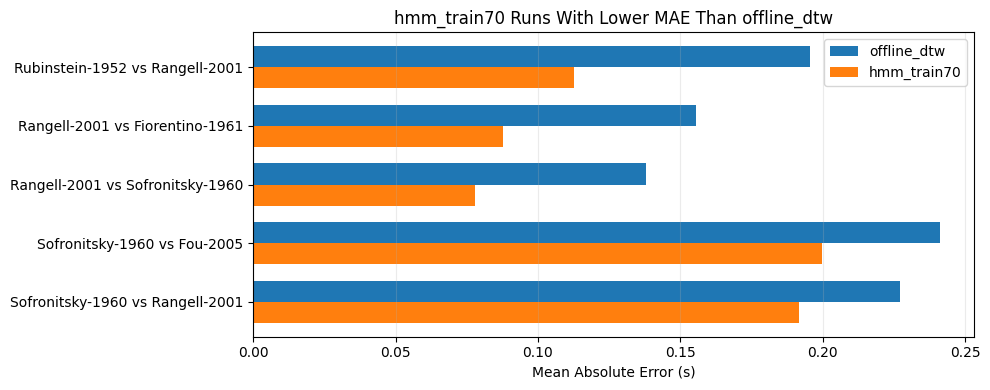

In [43]:
hmm_better_mae = pair_comparison[pair_comparison["delta_mean_abs_error_s"] < 0].sort_values("delta_mean_abs_error_s").copy()

if hmm_better_mae.empty:
    print(f"No {CANDIDATE} runs have lower pair-level MAE than {BASELINE}.")
else:
    def short_recording_label(recording_id: str) -> str:
        return str(recording_id).replace("Chopin_Op030No2_", "").split("_pid")[0]

    pair_metadata = pairs[["pair_id", "reference_id", "query_id"]].drop_duplicates("pair_id")
    hmm_better_mae = hmm_better_mae.merge(pair_metadata, on="pair_id", how="left")
    hmm_better_mae["label"] = hmm_better_mae["query_id"].map(short_recording_label) + " vs " + hmm_better_mae["reference_id"].map(short_recording_label)

    y = np.arange(len(hmm_better_mae))
    bar_height = 0.36
    fig, ax = plt.subplots(figsize=(10, max(4, 0.55 * len(hmm_better_mae))))
    ax.barh(y - bar_height / 2, hmm_better_mae["baseline_mean_abs_error_s"], height=bar_height, label=BASELINE)
    ax.barh(y + bar_height / 2, hmm_better_mae["candidate_mean_abs_error_s"], height=bar_height, label=CANDIDATE)
    ax.set_yticks(y)
    ax.set_yticklabels(hmm_better_mae["label"])
    ax.invert_yaxis()
    ax.set(title=f"{CANDIDATE} Runs With Lower MAE Than {BASELINE}", xlabel="Mean Absolute Error (s)")
    ax.grid(True, axis="x", alpha=0.25)
    ax.legend()
    plt.tight_layout()
    print(f"{CANDIDATE} has lower pair-level MAE than {BASELINE} on {len(hmm_better_mae)} of {len(pair_comparison)} runs.")
    plt.show()

## Bias, Drift, And Tempo Diagnostics

This helps separate locally noisy cases from systematically drifting cases.

In [44]:
def timing_diagnostics(beat_errors: pd.DataFrame, phase: str = "early") -> pd.DataFrame:
    subset = beat_errors[beat_errors["track_phase"] == phase].copy()

    def one_pair(group: pd.DataFrame) -> pd.Series:
        group = group.sort_values("beat_index")
        errors = group["error_s"].to_numpy(dtype=float)
        abs_errors = np.abs(errors)
        beats = group["beat_index"].to_numpy(dtype=float)
        ref_intervals = np.diff(group["reference_beat_time_s"].to_numpy(dtype=float))
        query_intervals = np.diff(group["query_beat_time_s"].to_numpy(dtype=float))
        slope = float(np.polyfit(beats, errors, 1)[0]) if len(beats) > 1 else np.nan
        ref_ibi = float(ref_intervals.mean()) if len(ref_intervals) else np.nan
        query_ibi = float(query_intervals.mean()) if len(query_intervals) else np.nan
        return pd.Series(
            {
                "reference_id": group["reference_id"].iloc[0],
                "query_id": group["query_id"].iloc[0],
                "mae": float(abs_errors.mean()),
                "medae": float(np.median(abs_errors)),
                "bias": float(errors.mean()),
                "abs_bias": float(abs(errors.mean())),
                "drift_s_per_beat": slope,
                "abs_drift_s_per_beat": abs(slope),
                "centered_mae": float(np.abs(errors - errors.mean()).mean()),
                "within_100ms": float((abs_errors <= 0.10).mean()),
                "ref_ibi_mean": ref_ibi,
                "query_ibi_mean": query_ibi,
                "tempo_ratio_query_over_ref": query_ibi / ref_ibi if ref_ibi and query_ibi else np.nan,
            }
        )

    return subset.groupby(["method_name", "pair_id"]).apply(one_pair, include_groups=False).reset_index()


diagnostics = timing_diagnostics(beat_errors, phase="early") if not beat_errors.empty else pd.DataFrame()
candidate_diag = diagnostics[diagnostics["method_name"] == CANDIDATE].copy()

diag_cols = [
    "pair_id",
    "reference_id",
    "query_id",
    "mae",
    "medae",
    "bias",
    "drift_s_per_beat",
    "centered_mae",
    "within_100ms",
    "ref_ibi_mean",
    "query_ibi_mean",
    "tempo_ratio_query_over_ref",
]

display(candidate_diag.sort_values("mae")[[c for c in diag_cols if c in candidate_diag.columns]].head(TOP_N))

if not candidate_diag.empty:
    top = candidate_diag.sort_values("mae").head(TOP_N)
    rest = candidate_diag.drop(top.index)
    compare_cols = ["mae", "medae", "bias", "abs_bias", "drift_s_per_beat", "abs_drift_s_per_beat", "centered_mae", "within_100ms"]
    display(pd.concat({"top_cases": top[compare_cols].mean(), "rest": rest[compare_cols].mean()}, axis=1))

    corr_cols = ["mae", "medae", "bias", "abs_bias", "drift_s_per_beat", "abs_drift_s_per_beat", "centered_mae", "tempo_ratio_query_over_ref"]
    display(candidate_diag[corr_cols].corr()[["mae"]].sort_values("mae", ascending=False))

,pair_id,reference_id,query_id,mae,medae,bias,drift_s_per_beat,centered_mae,within_100ms,ref_ibi_mean,query_ibi_mean,tempo_ratio_query_over_ref
335,Chopin_Op030No2_Sofronitsky-1960_pid5667291-15...,Chopin_Op030No2_Sofronitsky-1960_pid5667291-15,Chopin_Op030No2_Rangell-2001_pid9094-19,0.071042,0.026734,-0.044586,-0.000628,0.076254,0.845361,0.301875,0.420625,1.393375
286,Chopin_Op030No2_Rubinstein-1939_pid9049-19__Ch...,Chopin_Op030No2_Rubinstein-1939_pid9049-19,Chopin_Op030No2_Rubinstein-1952_pid9075-19,0.075950,0.026984,-0.027725,-0.000409,0.087338,0.793814,0.396771,0.445104,1.121817
285,Chopin_Op030No2_Rubinstein-1939_pid9049-19__Ch...,Chopin_Op030No2_Rubinstein-1939_pid9049-19,Chopin_Op030No2_Rangell-2001_pid9094-19,0.084786,0.030476,-0.049902,-0.000600,0.098572,0.762887,0.396771,0.420625,1.060121
145,Chopin_Op030No2_Francois-1956_pid9070b-02__Cho...,Chopin_Op030No2_Francois-1956_pid9070b-02,Chopin_Op030No2_Rangell-2001_pid9094-19,0.084887,0.025011,-0.054653,-0.000058,0.091110,0.752577,0.370208,0.420625,1.136185
337,Chopin_Op030No2_Sofronitsky-1960_pid5667291-15...,Chopin_Op030No2_Sofronitsky-1960_pid5667291-15,Chopin_Op030No2_Rubinstein-1952_pid9075-19,0.085440,0.028095,-0.046298,-0.001496,0.095813,0.752577,0.301875,0.445104,1.474465
101,Chopin_Op030No2_Fiorentino-1961_pid9065-14__Ch...,Chopin_Op030No2_Fiorentino-1961_pid9065-14,Chopin_Op030No2_Rangell-2001_pid9094-19,0.086920,0.035488,-0.055691,-0.000709,0.098902,0.783505,0.359271,0.420625,1.170774
261,Chopin_Op030No2_Olejniczac-1990_pid9100b-19__C...,Chopin_Op030No2_Olejniczac-1990_pid9100b-19,Chopin_Op030No2_Uninsky-1959_pid9061-19,0.087909,0.032698,-0.050064,-0.000881,0.098363,0.711340,0.334307,0.473614,1.416704
12,Chopin_Op030No2_Ashkenazy-1982_pid50848-03__Ch...,Chopin_Op030No2_Ashkenazy-1982_pid50848-03,Chopin_Op030No2_Poblocka-1999_pid9093-19,0.089721,0.040794,-0.005053,-0.000637,0.090076,0.690722,0.314688,0.412324,1.310264
341,Chopin_Op030No2_Sofronitsky-1960_pid5667291-15...,Chopin_Op030No2_Sofronitsky-1960_pid5667291-15,Chopin_Op030No2_Uninsky-1959_pid9061-19,0.090252,0.039592,-0.014413,-0.000170,0.088648,0.742268,0.301875,0.473614,1.568907
258,Chopin_Op030No2_Olejniczac-1990_pid9100b-19__C...,Chopin_Op030No2_Olejniczac-1990_pid9100b-19,Chopin_Op030No2_Shebanova-2002_pid9072-19,0.092417,0.034944,-0.023790,0.000848,0.096297,0.690722,0.334307,0.384567,1.150342


,top_cases,rest
mae,0.087974,0.629343
medae,0.034503,0.416434
bias,-0.041149,-0.389495
abs_bias,0.041149,0.533174
drift_s_per_beat,-0.000482,-0.008985
abs_drift_s_per_beat,0.000602,0.011589
centered_mae,0.093885,0.551969
within_100ms,0.738144,0.514931


,mae
mae,1.000000
abs_bias,0.988834
centered_mae,0.936203
medae,0.928550
abs_drift_s_per_beat,0.910179
tempo_ratio_query_over_ref,-0.048188
bias,-0.785752
drift_s_per_beat,-0.798967


## Inspect One Pair

Set `PAIR_ID` to any pair from the tables above.

In [45]:
PAIR_ID = good_absolute["pair_id"].iloc[0] if len(good_absolute) else None
PAIR_ID

'Chopin_Op030No2_Sofronitsky-1960_pid5667291-15__Chopin_Op030No2_Rangell-2001_pid9094-19'

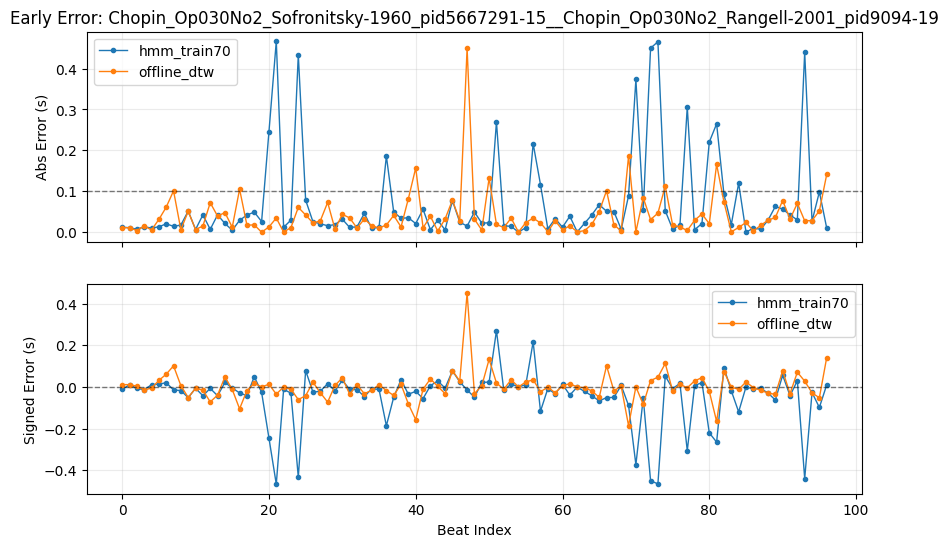

,method_name,mae,medae,rmse,p95,within_100ms,bias,max_abs_error_s
1,offline_dtw,0.040863,0.027777,0.069859,0.134150,0.896907,0.001910,0.449570
0,hmm_train70,0.071042,0.026734,0.133130,0.385403,0.845361,-0.044586,0.466802


,method_name,beat_index,reference_beat_time_s,query_beat_time_s,estimated_reference_time_s,error_s,abs_error_s
64676,hmm_train70,21,7.357959,11.827982,6.891157,-0.466802,0.466802
64728,hmm_train70,73,23.197959,33.657982,22.732336,-0.465623,0.465623
64727,hmm_train70,72,22.717959,33.097982,22.267937,-0.450022,0.450022
134761,offline_dtw,47,14.677959,24.107982,15.127529,0.449570,0.449570
64748,hmm_train70,93,28.837959,40.357982,28.398005,-0.439954,0.439954
64679,hmm_train70,24,8.397857,13.468163,7.964444,-0.433413,0.433413
64725,hmm_train70,70,21.967959,32.257982,21.594558,-0.373401,0.373401
64732,hmm_train70,77,24.477959,35.155011,24.171973,-0.305986,0.305986
64706,hmm_train70,51,16.517959,26.131156,16.788027,0.270068,0.270068
134783,offline_dtw,69,21.647959,31.847982,21.461950,-0.186009,0.186009


In [46]:
def inspect_pair(beat_errors: pd.DataFrame, pair_id: str, methods: tuple[str, ...] = (BASELINE, CANDIDATE), phase: str = "early") -> None:
    subset = beat_errors[(beat_errors["pair_id"] == pair_id) & (beat_errors["track_phase"] == phase) & (beat_errors["method_name"].isin(methods))].copy()
    if subset.empty:
        print("No rows found for", pair_id)
        return

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    for method, group in subset.groupby("method_name"):
        group = group.sort_values("beat_index")
        axes[0].plot(group["beat_index"], group["abs_error_s"], marker=".", linewidth=1, label=method)
        axes[1].plot(group["beat_index"], group["error_s"], marker=".", linewidth=1, label=method)

    axes[0].axhline(0.10, color="black", linestyle="--", linewidth=1, alpha=0.5)
    axes[0].set(ylabel="Abs Error (s)", title=f"{phase.title()} Error: {pair_id}")
    axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1, alpha=0.5)
    axes[1].set(xlabel="Beat Index", ylabel="Signed Error (s)")
    for ax in axes:
        ax.grid(True, alpha=0.25)
        ax.legend()
    plt.show()

    rows = []
    for method, group in subset.groupby("method_name"):
        group = group.sort_values("beat_index")
        errors = group["error_s"].to_numpy(dtype=float)
        abs_errors = np.abs(errors)
        rows.append(
            {
                "method_name": method,
                "mae": abs_errors.mean(),
                "medae": np.median(abs_errors),
                "rmse": np.sqrt(np.mean(errors * errors)),
                "p95": np.quantile(abs_errors, 0.95),
                "within_100ms": (abs_errors <= 0.10).mean(),
                "bias": errors.mean(),
                "max_abs_error_s": abs_errors.max(),
            }
        )
    display(pd.DataFrame(rows).sort_values("mae"))

    worst = subset.sort_values("abs_error_s", ascending=False).groupby("method_name").head(8)
    display(worst[["method_name", "beat_index", "reference_beat_time_s", "query_beat_time_s", "estimated_reference_time_s", "error_s", "abs_error_s"]])


inspect_pair(beat_errors, PAIR_ID, phase="early")